# Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from skimage.measure import shannon_entropy
from skimage.morphology import white_tophat, disk
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.exposure import rescale_intensity
from skimage.util import img_as_float, img_as_ubyte
from skimage.restoration import denoise_bilateral
from scipy.ndimage import laplace
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import random

# Visualización de datos

In [3]:
DATA_DIR = Path("data")
image_files = list(DATA_DIR.glob("*.jpg"))

statistics = []
corrupted_files = []

In [4]:
for img_file in tqdm(image_files, desc="Processing images"):
    try:
        with Image.open(img_file) as img:
            img_gray = img.convert('L')
            img_array_gray = np.array(img_gray)
            img_array = np.array(img)

            width, height = img.size
            mode = img.mode

            # Look for NaN values in the image array
            has_nan = np.isnan(img_array).any()

            #  Pixel value statistics
            mean_val = np.mean(img_array)
            std_val = np.std(img_array)
            min_val = np.min(img_array)
            max_val = np.max(img_array)

            # Entropy: Measure of complexity/information content
            ent = shannon_entropy(img_array)
            
            # Sharpness: Variance of the Laplacian
            sharpness = np.var(laplace(img_array_gray))

            statistics.append({
                "filename": img_file.name,
                "width": width,
                "height": height,
                "mode": mode,
                "mean_intensity": mean_val,
                "std_intensity": std_val,
                "min_intensity": min_val,
                "max_intensity": max_val,
                "entropy": ent,
                "sharpness": sharpness,
                "has_nan": has_nan
            })
    except Exception as e:
        # If there's an corrupted file
        corrupted_files.append({'filename': img_file.name, 'error': str(e)})

df  = pd.DataFrame(statistics)

Processing images: 100%|██████████| 5446/5446 [05:03<00:00, 17.96it/s]


## Estadisticas descriptivas

In [5]:
corrupted_files

[{'filename': 'J154951.73+160402.5.jpg',
  'error': 'image file is truncated (80 bytes not processed)'},
 {'filename': 'J114739.51+100035.4.jpg',
  'error': 'image file is truncated (93 bytes not processed)'},
 {'filename': 'J134807.42+144711.9.jpg',
  'error': 'image file is truncated (8 bytes not processed)'},
 {'filename': 'J142043.76+053351.6.jpg',
  'error': 'image file is truncated (110 bytes not processed)'},
 {'filename': 'J150244.67+261252.1.jpg',
  'error': 'image file is truncated (99 bytes not processed)'},
 {'filename': 'J160131.59+362834.9.jpg',
  'error': 'image file is truncated (44 bytes not processed)'},
 {'filename': 'J143659.70+133059.7.jpg',
  'error': 'image file is truncated (109 bytes not processed)'},
 {'filename': 'J234447.50+254133.9.jpg',
  'error': 'image file is truncated (51 bytes not processed)'},
 {'filename': 'J145430.69+094226.1.jpg',
  'error': 'image file is truncated (52 bytes not processed)'},
 {'filename': 'J152516.45+532425.4.jpg',
  'error': 'i

In [6]:
df.head()

,filename,width,height,mode,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness,has_nan
0,J115411.04+305652.3.jpg,800,800,RGB,40.513945,30.896488,0,255,6.336151,14140.743585,False
1,J090105.65+082536.7.jpg,800,800,RGB,37.123586,26.803691,0,255,6.368993,13101.412283,False
2,J070552.49+655739.9.jpg,800,800,RGB,36.745555,22.203929,0,255,5.971673,10077.102353,False
3,J083907.66+043402.4.jpg,800,800,RGB,53.435871,42.205530,0,255,6.662711,11292.742344,False
4,J103154.70-031818.9.jpg,800,800,RGB,34.319342,20.750330,0,255,6.150319,12495.401202,False


In [7]:
df.describe()

,width,height,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness
count,5003.0,5003.0,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000
mean,800.0,800.0,40.309662,27.918231,0.031581,254.568259,6.293839,13425.265836
std,0.0,0.0,10.278925,6.440160,0.964899,5.656597,0.321319,1233.313304
min,800.0,800.0,31.961873,0.000000,0.000000,32.000000,0.000000,0.000000
25%,800.0,800.0,36.755140,23.927473,0.000000,255.000000,6.153893,12977.203434
50%,800.0,800.0,38.564674,27.241475,0.000000,255.000000,6.309219,13696.863947
75%,800.0,800.0,41.401478,30.945381,0.000000,255.000000,6.464228,14241.604985
max,800.0,800.0,219.912874,100.133838,41.000000,255.000000,7.734024,15249.277823


## Visualización

/tmp/ipykernel_1442487/634956432.py:31: RuntimeWarning: overflow encountered in scalar add
  plt.text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')


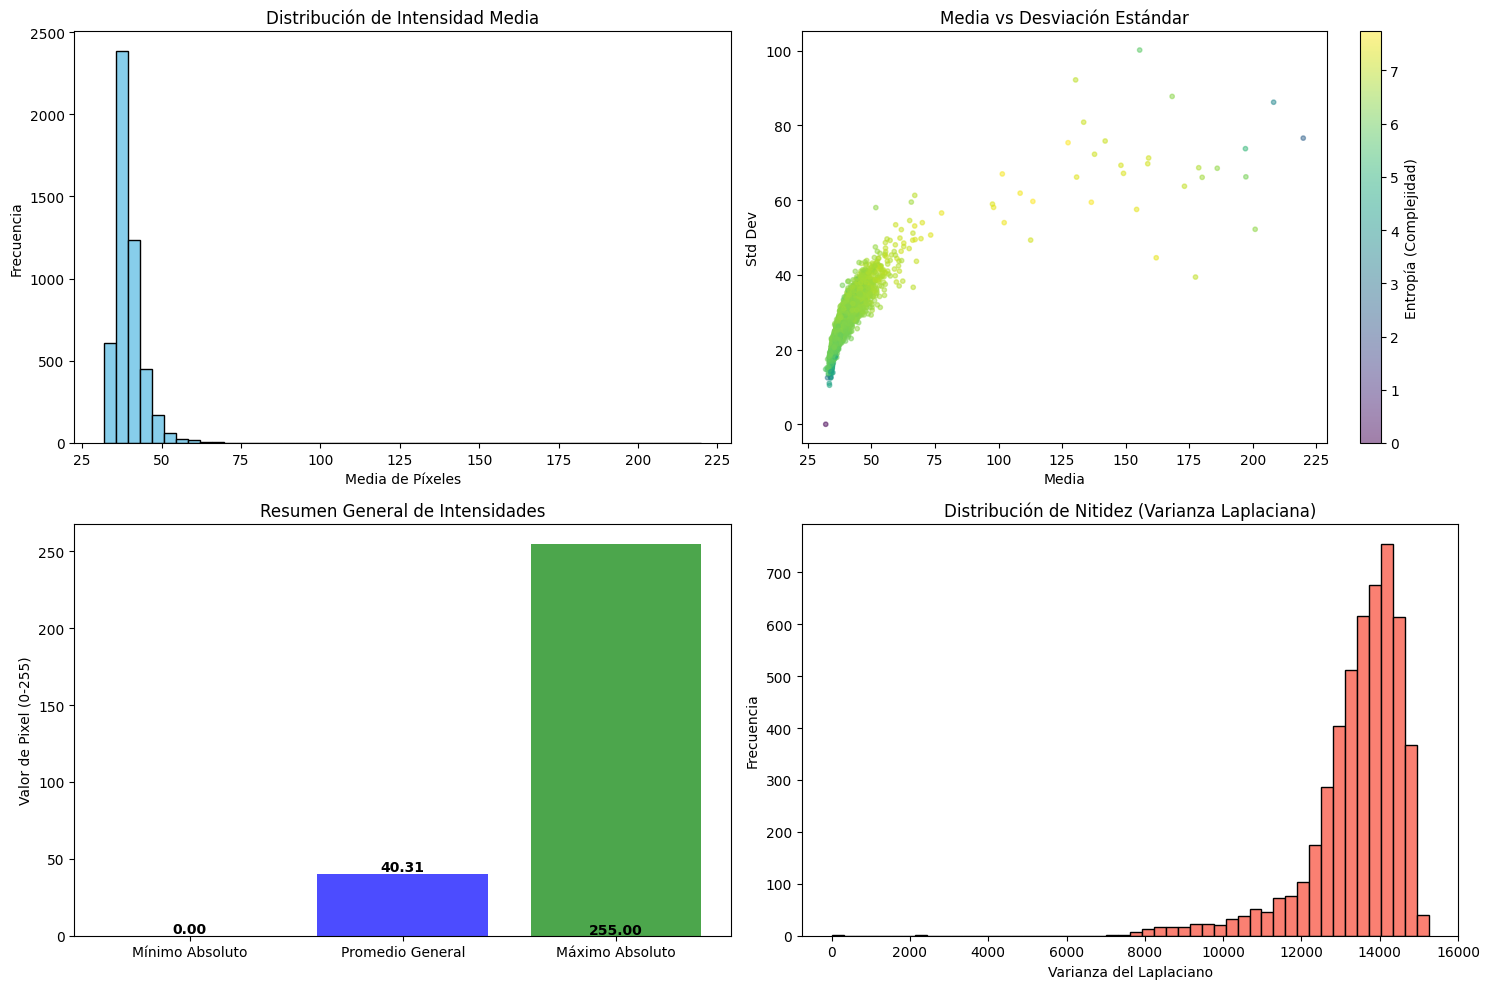

In [8]:
plt.figure(figsize=(15, 10))
# Subplot 1: Histogram of intensities
plt.subplot(2, 2, 1)
plt.hist(df['mean_intensity'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Intensidad Media')
plt.xlabel('Media de Píxeles')
plt.ylabel('Frecuencia')

# Subplot 2: Mean vs Std (Contrast)
plt.subplot(2, 2, 2)
plt.scatter(df['mean_intensity'], df['std_intensity'], alpha=0.5, s=10, c=df['entropy'], cmap='viridis')
plt.colorbar(label='Entropía (Complejidad)')
plt.title('Media vs Desviación Estándar')
plt.xlabel('Media')
plt.ylabel('Std Dev')

# Subplot 3: Bar chart of global Min, Mean, Max
plt.subplot(2, 2, 3)
global_min = df['min_intensity'].min()
global_mean = df['mean_intensity'].mean()
global_max = df['max_intensity'].max()

labels = ['Mínimo Absoluto', 'Promedio General', 'Máximo Absoluto']
values = [global_min, global_mean, global_max]
colors = ['red', 'blue', 'green']

plt.bar(labels, values, color=colors, alpha=0.7)
plt.title('Resumen General de Intensidades')
plt.ylabel('Valor de Pixel (0-255)')
for i, v in enumerate(values):
    plt.text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')

# Subplot 4: Sharpness Distribution
plt.subplot(2, 2, 4)
plt.hist(df['sharpness'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribución de Nitidez (Varianza Laplaciana)')
plt.xlabel('Varianza del Laplaciano')
plt.ylabel('Frecuencia')

plt.tight_layout()

plt.tight_layout()

# Sample size

In [9]:
def calculate_sample_size(N: int, confidence_level: float = 0.95, margin_error: float = 0.03) -> int:
    """Calcula el tamaño de muestra necesario para una población finita.
    Args:        
        N (int): Tamaño de la población.
        confidence_level (float): Nivel de confianza (default 0.95).
        margin_error (float): Margen de error permitido (default 0.03).
    Returns:        
        int: Tamaño de muestra necesario.
    """
    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    Z = z_map.get(confidence_level, 1.96) 
    p = 0.5
    n0 = (Z**2 * p * (1-p)) / (margin_error**2)
    n = n0 / (1 + (n0 - 1) / N)
    return int(np.ceil(n))

In [10]:
N = len(df)
n_target = calculate_sample_size(N)
print(f"For a population of {N}, a significant sample size is {n_target} (95% CI, 3% MoE)")

For a population of 5003, a significant sample size is 880 (95% CI, 3% MoE)


Utilizando la fórmula de Cochran con corrección para población finita (N=5003), se determinó que una muestra de 880 imágenes es
      suficiente para un 95% de confianza con un 3% de margen de error.

In [11]:
def perform_sampling(df: pd.DataFrame, target_n: int) -> pd.DataFrame:
    """
    Performs Stratified Proportional Sampling using KMeans.
    Args:
        df (pd.DataFrame): DataFrame containing image statistics.
        target_n (int): Desired sample size.
    Returns:
        pd.DataFrame: Sampled DataFrame with significant images.
    """
    print(f"\n--- Statistical Sampling (Target n={target_n}) ---")
    sampling_features = ['mean_intensity', 'std_intensity', 'entropy', 'sharpness']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[sampling_features])
    
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['strata'] = kmeans.fit_predict(X_scaled)
    
    sample_df = df.groupby('strata', group_keys=False).apply(
        lambda x: x.sample(n=int(np.ceil(target_n * len(x) / len(df))), random_state=42)
    ).head(target_n)
    
    print(f"Sample selected with {len(sample_df)} images.")
    sample_df.to_csv('significant_sample.csv', index=False)
    return sample_df

In [12]:
sample_df = perform_sampling(df, n_target)
sample_df.head()


--- Statistical Sampling (Target n=880) ---
Sample selected with 880 images.


,filename,width,height,mode,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness,has_nan
528,J074321.08+173617.2.jpg,800,800,RGB,42.513907,31.711176,0,255,6.498445,13670.824544,False
1086,J115428.07+262854.5.jpg,800,800,RGB,47.811511,38.945569,0,255,6.743539,14294.641777,False
3238,J100327.20-013244.9.jpg,800,800,RGB,46.924266,41.060082,0,255,6.550957,13198.862694,False
4576,J074516.67+460758.3.jpg,800,800,RGB,45.794397,32.858985,0,255,6.370509,14190.851805,False
981,J144957.01+331357.6.jpg,800,800,RGB,43.647432,29.756518,0,255,6.343374,14755.613404,False


In [13]:
def validate_sample(population_df: pd.DataFrame, sample_df: pd.DataFrame) -> None:
    """
    Validates the sample using Kolmogorov-Smirnov test.
    Args:
        population_df (pd.DataFrame): The original population DataFrame.
        sample_df (pd.DataFrame): The sampled DataFrame to validate.
    """
    print("\n--- Statistical Validation ---")
    metrics = ['mean_intensity', 'entropy', 'sharpness']
    results = []
    for metric in metrics:
        ks_stat, p_value = stats.ks_2samp(population_df[metric], sample_df[metric])
        results.append({
            'Metric': metric,
            'KS Statistic': ks_stat,
            'P-Value': p_value,
            'Significant Difference?': 'Yes' if p_value < 0.05 else 'No'
        })
    print(pd.DataFrame(results))
    
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        plt.hist(population_df[metric], bins=30, alpha=0.5, label='Población', density=True)
        plt.hist(sample_df[metric], bins=30, alpha=0.5, label='Muestra', density=True)
        plt.title(f'Distribución de {metric}')
        plt.legend()
    plt.tight_layout()


--- Statistical Validation ---
           Metric  KS Statistic   P-Value Significant Difference?
0  mean_intensity      0.019903  0.921562                      No
1         entropy      0.019495  0.932423                      No
2       sharpness      0.023594  0.788531                      No


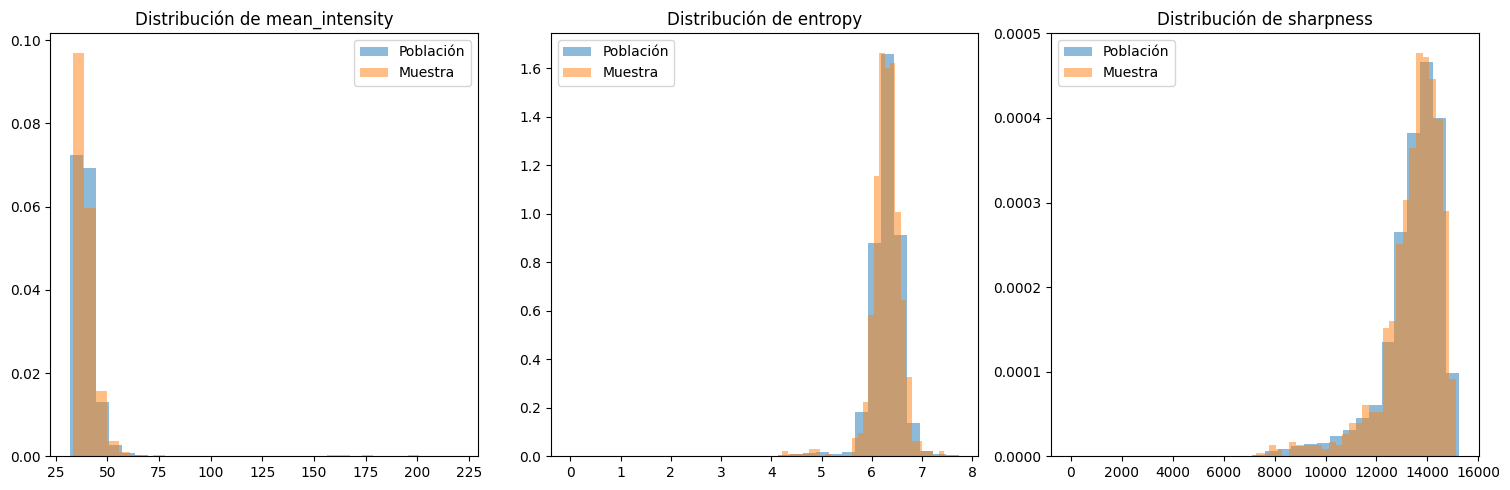

In [14]:
validate_sample(df, sample_df)


Se utilizó K-Means para agrupar las imágenes en 5 estratos (basados en intensidad, entropía y nitidez) y asegurar que la muestra
      conserve la diversidad del dataset original (imágenes oscuras, complejas, con mucho ruido, etc.). La prueba de Kolmogorov-Smirnov confirmó que no hay diferencias significativas entre la muestra y la población (P-values > 0.78 para todas las
      métricas).

# Limpieza de las imágenes

In [2]:
CSV_PATH = Path('significant_sample.csv')
SOURCE_PATH = Path('data')
TARGET_PATH = Path('data/cleaned_sample')

sample_df = pd.read_csv(CSV_PATH)

## Analisis estadistico del sample

In [ ]:
def analyze_dataset_stats(csv_path='significant_sample.csv', source_dir='data'):
    df = pd.read_csv(csv_path)
    source_path = Path(source_dir)
    
    # Arreglos para almacenar métricas de todo el dataset
    bg_estimates = {'R': [], 'G': [], 'B': []}
    sigma_estimates = {'R': [], 'G': [], 'B': []}
    snr_estimates = {'R': [], 'G': [], 'B': []}
    
    print(f"--- Iniciando Extracción Estadística Global: {len(df)} imágenes ---")
    
    for filename in tqdm(df['filename'], desc="Analizando varianza y señal"):
        img_file = source_path / filename
        if not img_file.exists():
            continue
            
        try:
            with Image.open(img_file) as img:
                img_array = img_as_float(np.array(img))
            
            # Procesamiento para RGB
            if img_array.ndim == 3:
                for i, color in enumerate(['R', 'G', 'B']):
                    channel = img_array[:,:,i]
                    
                    median_bg = np.median(channel)
                    mad = stats.median_abs_deviation(channel.flatten())
                    sigma_est = 1.4826 * mad
                    
                    max_val = np.max(channel)
                    snr_peak = (max_val - median_bg) / sigma_est if sigma_est > 0 else 0
                    
                    bg_estimates[color].append(median_bg)
                    sigma_estimates[color].append(sigma_est)
                    snr_estimates[color].append(snr_peak)
        except Exception as e:
            print(f"Error procesando matriz de {filename}: {e}")
            
    # Cálculo de hiperparámetros globales del dataset
    print("\n--- Resultados Globales del Dataset ---")
    for color in ['R', 'G', 'B']:
        if not bg_estimates[color]:
            continue
            
        global_bg = np.median(bg_estimates[color])
        global_sigma = np.median(sigma_estimates[color])
        global_snr = np.median(snr_estimates[color])
        max_sigma = np.percentile(sigma_estimates[color], 95) # Varianza en el peor escenario (p95)
        
        print(f"\nCanal {color}:")
        print(f"  Fondo base global (Mediana): {global_bg:.4f}")
        print(f"  Ruido típico (Sigma mediana): {global_sigma:.4f}")
        print(f"  Ruido máximo esperado (Sigma p95): {max_sigma:.4f}")
        print(f"  Peak SNR global representativo: {global_snr:.2f}")

if __name__ == "__main__":
    analyze_dataset_stats()

--- Iniciando Extracción Estadística Global: 880 imágenes ---


Analizando varianza y señal: 100%|██████████| 880/880 [00:57<00:00, 15.34it/s]


--- Resultados Globales del Dataset ---

Canal R:
  Fondo base global (Mediana): 0.1412
  Ruido típico (Sigma mediana): 0.0872
  Ruido máximo esperado (Sigma p95): 0.1221
  Peak SNR global representativo: 9.89

Canal G:
  Fondo base global (Mediana): 0.1333
  Ruido típico (Sigma mediana): 0.0640
  Ruido máximo esperado (Sigma p95): 0.0872
  Peak SNR global representativo: 13.55

Canal B:
  Fondo base global (Mediana): 0.1333
  Ruido típico (Sigma mediana): 0.0581
  Ruido máximo esperado (Sigma p95): 0.0756
  Peak SNR global representativo: 13.43


In [ ]:
def deep_learning_prep_pipeline(img_array):
    """
    Pipeline optimizado para preservar gradientes espaciales 
    para modelos de segmentación convolucional.
    """
    img_float = img_as_float(img_array)
    
    # Filtrado Bilateral: Reduce ruido de alta frecuencia en el fondo 
    # mientras preserva estrictamente los bordes
    # sigma_color: Controla cuánto se mezclan colores distintos. Un valor bajo evita difuminar bordes.
    # sigma_spatial: Radio de influencia espacial.
    denoised = denoise_bilateral(
        img_float, 
        win_size=9, 
        sigma_color=0.05, 
        sigma_spatial=15, 
        channel_axis=-1
    )
    
    # Normalización Lineal Robusta
    # Evitamos distorsiones no lineales (asinh) que confunden al modelo.
    # Recortamos el 1% inferior y superior para descartar píxeles calientes y ruido puro,
    # reescalando el rango dinámico real de la estructura al rango [0, 1].
    p_low, p_high = np.percentile(denoised, (1.0, 99.5))
    
    if p_high > p_low:
        normalized = np.clip((denoised - p_low) / (p_high - p_low), 0, 1)
    else:
        normalized = denoised # Fallback de seguridad matemática
        
    return img_as_ubyte(normalized)

def run_dl_pipeline():
    df = pd.read_csv(CSV_PATH)
    TARGET_PATH.mkdir(parents=True, exist_ok=True)
    
    success = 0
    errors = 0
    
    for filename in tqdm(df['filename'], desc="Preparando dataset"):
        img_file = SOURCE_PATH / filename
        if not img_file.exists():
            continue
            
        try:
            with Image.open(img_file) as img:
                img_array = np.array(img.convert('RGB')) 
                
                cleaned_array = deep_learning_prep_pipeline(img_array)
                
                Image.fromarray(cleaned_array).save(TARGET_PATH / filename, quality=95)
                success += 1
        except Exception as e:
            errors += 1
            
if __name__ == "__main__":
    run_dl_pipeline()

Preparando dataset: 100%|██████████| 880/880 [07:23<00:00,  1.98it/s]


Visualizamos para comparar los resultados

In [4]:
source_files = set([f.name for f in SOURCE_PATH.glob("*.jpg")])
target_files = set([f.name for f in TARGET_PATH.glob("*.jpg")])

common_files = sorted(list(source_files.intersection(target_files)))



Found 880 common images. Selecting 5 for visualization.


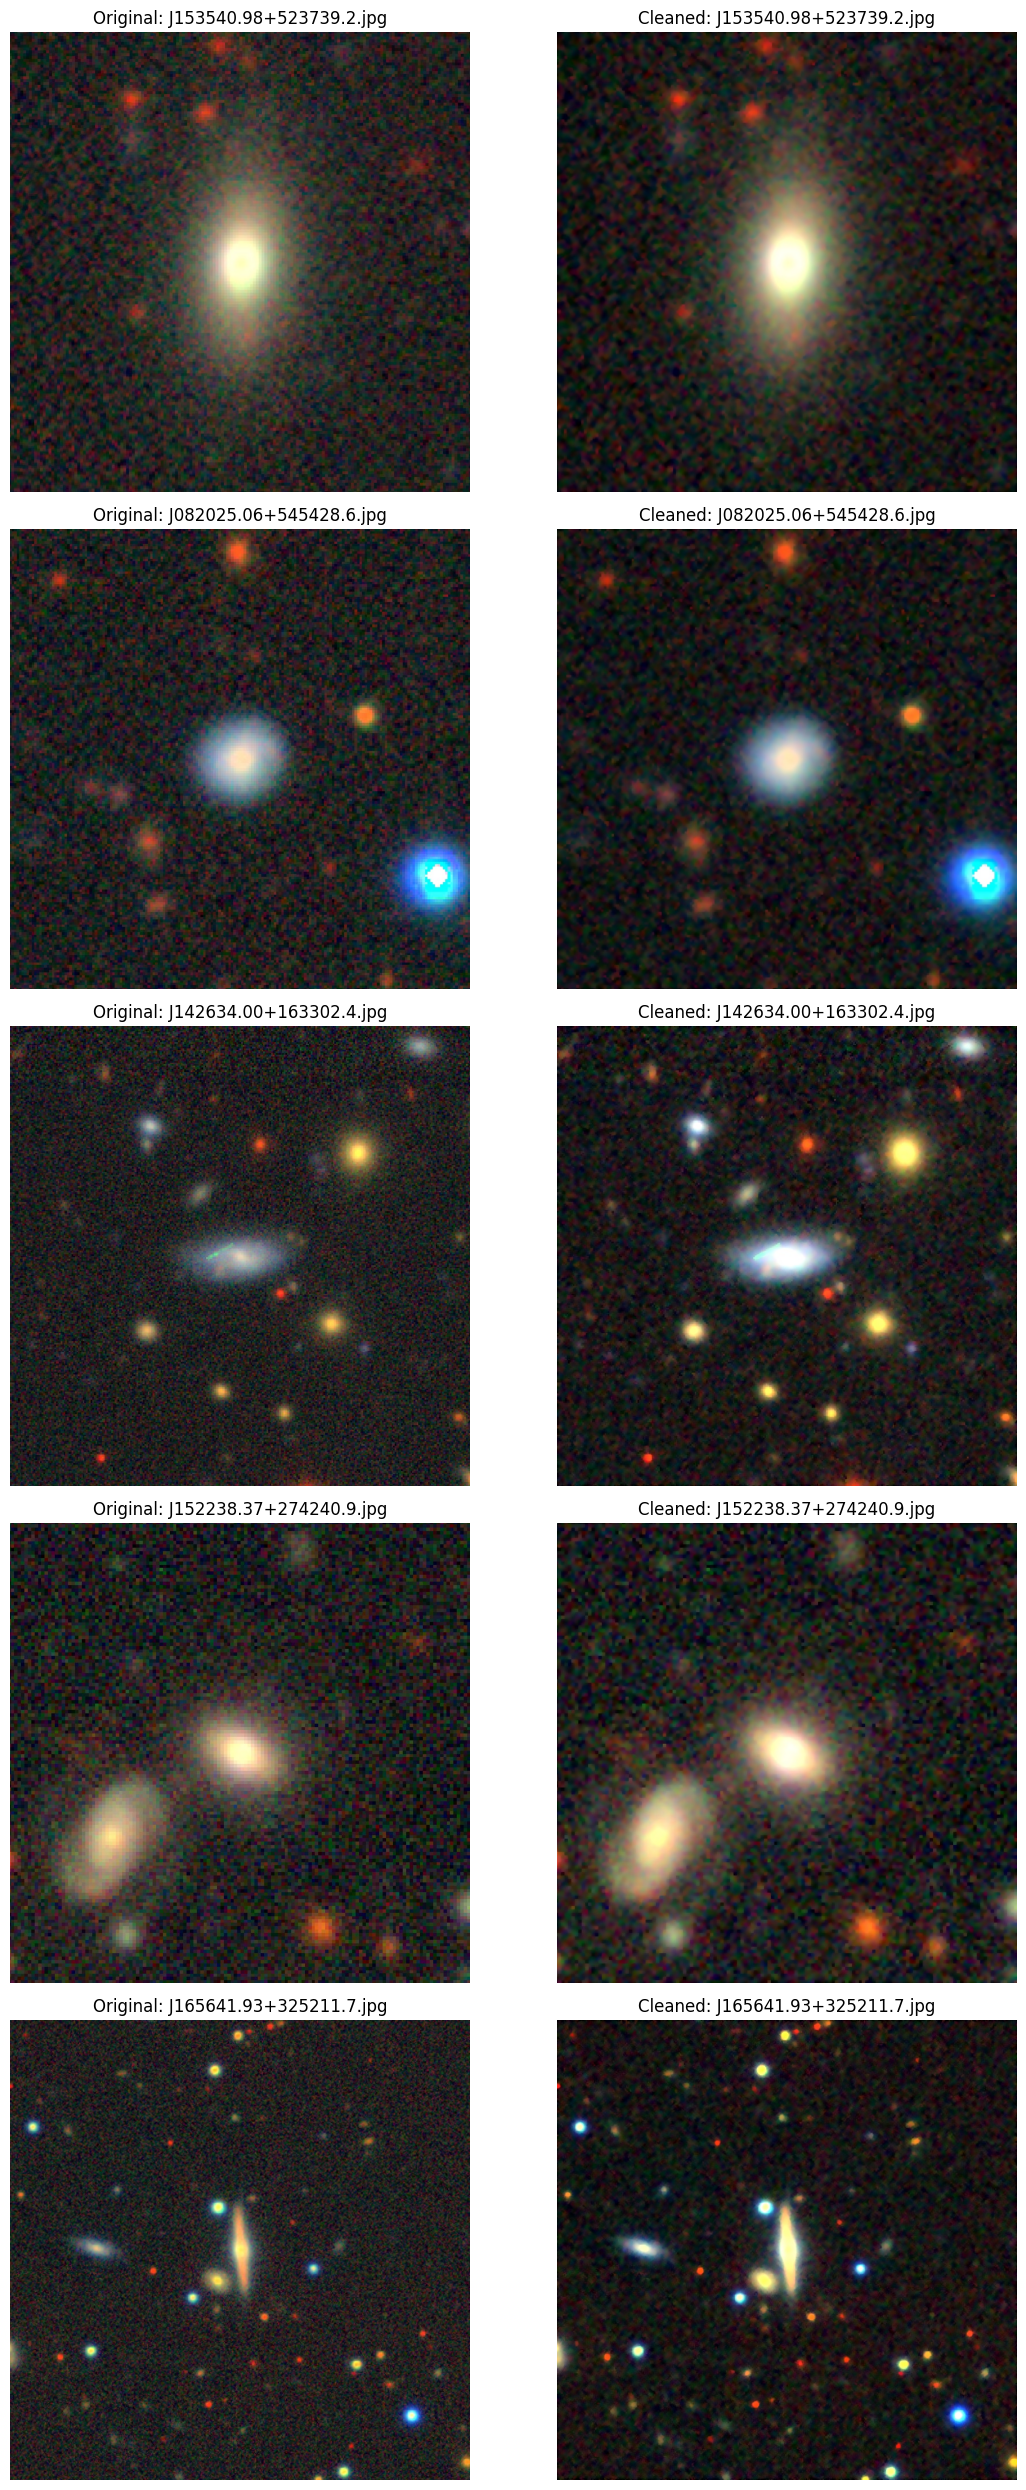

In [5]:
n_to_show = min(5, len(common_files))
print(f"Found {len(common_files)} common images. Selecting {n_to_show} for visualization.")
sample = random.sample(common_files, n_to_show)

fig, axes = plt.subplots(n_to_show, 2, figsize=(12, 5 * n_to_show))

for i, filename in enumerate(sample):
    img_orig = Image.open(SOURCE_PATH / filename)
    axes[i][0].imshow(img_orig)
    axes[i][0].set_title(f"Original: {filename}")
    axes[i][0].axis('off')
    
    img_clean = Image.open(TARGET_PATH / filename)
    axes[i][1].imshow(img_clean)
    axes[i][1].set_title(f"Cleaned: {filename}")
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()